# Riparian Encroachment Detection & Structure Segmentation

### Automated Mapping of Informal Settlements Within Regulated River Buffer Zones — Kasarani, Nairobi

---

## 1. Problem Statement

Kenya's Water Act designates a mandatory riparian buffer along all rivers and streams — a
setback zone in which permanent construction is legally prohibited. In rapidly urbanizing
areas such as **Kasarani, Nairobi**, informal settlements have expanded directly into these
buffer zones, increasing flood risk, degrading water quality, and complicating enforcement
for county planning authorities.

Manual field surveys cannot keep pace with this growth. This notebook builds an automated,
satellite-imagery-driven pipeline to **detect, count, and measure** individual structures
encroaching on the riparian buffer, producing a GIS-ready output for compliance reporting.

## 2. The Core Technical Challenge: "The Blob Limitation"

Informal settlements are characterized by **high roof density** — corrugated iron (mabati)
sheets are frequently butted directly against neighboring structures, with little to no
visible gap between rooftops.

A standard single-stage computer vision model (e.g. a segmentation network run directly on
raw imagery, or basic connected-component analysis on a material mask) treats spectrally
and spatially continuous roof material as **one object**. The result:

- Ten adjacent one-room dwellings are detected as **a single building footprint**.
- Building **counts are severely undercounted**, sometimes by an order of magnitude.
- Footprint area calculations are meaningless, since one "structure" spans multiple households.

> **Key Takeaway:** For encroachment analytics to be legally and administratively useful,
> the pipeline must resolve *individual* structures, not just detect "built-up area." This
> is the design driver behind the two-step methodology below.

## 3. Methodology Overview

This pipeline decouples **material classification** from **instance boundary delineation**,
using a purpose-built model for each task:

| Step | Model | Role |
|------|-------|------|
| 1. Material Highlighter | Random Forest (pixel-level) | Isolates corrugated iron roof pixels from vegetation, bare soil, and water |
| 2. Structure Boundary Tracer | YOLOv8-seg (instance segmentation) | Splits touching roofs into distinct, countable structures using shadow lines, ridgelines, and corner cues |

The output of Step 1 (a binary material mask) becomes the label source for Step 2. Step 2's
output polygons are then georeferenced and converted into planning-grade metrics.

In [1]:
! pip install pystac-client stackstac rioxarray rasterio geopandas

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 2.1 MB/s eta 0:00:06
   ------- -------------------------------- 2.1/11.3 MB 4.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.3 MB 5.6 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.3 MB 4.7 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.3 MB 5.8 MB/s eta 0:00:01
   ------------------------ --------------- 7.1/11.3 MB 5.9 MB/s eta 0:00:01
   ------------------------- -------------- 7.3/11.3 MB 4.9 MB/s eta 0:00:01
   --------------------------------- ------ 9.4/11.3 MB 5.5 MB/s eta 0:00:01
   ------------------------------------ --- 10.5/11.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 5.2 MB/s  0:00:02
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------

In [4]:
! pip install osmnx geopandas pystac-client stackstac rioxarray rasterio

## Data Acquisition: Study Area & Source Imagery

Before classification can begin, the pipeline assembles its two core spatial inputs:

- **River network (vector):** Pulled from OpenStreetMap via `osmnx`, filtered to
  `waterway` tags (`river`, `stream`) for the Kasarani, Nairobi study area. This defines
  the centerlines from which the regulated buffer zone is constructed.
- **Satellite composite (raster):** A multi-band optical composite retrieved and stacked
  via `pystac-client` / `stackstac`, clipped to the riparian buffer extent using `rioxarray`.

> **Key Takeaway:** All downstream classification is only as good as this alignment step —
> the raster and vector layers must share a consistent CRS before any pixel-level analysis
> is trustworthy.

In [6]:
import osmnx as ox
import geopandas as gpd
from pystac_client import Client
import stackstac
import rioxarray as rxr

# 1. FETCH RIVER VECTORS ONLINE (OpenStreetMap)
print("Downloading river data for Kasarani...")
place_name = "Kasarani, Nairobi, Kenya"

# Use features_from_place instead of geometries_from_place
rivers = ox.features_from_place(place_name, tags={"waterway": ["river", "stream"]})
rivers = rivers.reset_index()
rivers = rivers[rivers.geometry.type.isin(["LineString", "MultiLineString"])]

# 2. TRANSFORM & BUFFER GEOMETRY (EPSG:32737 - UTM Zone 37S)
TARGET_CRS = "EPSG:32737"
rivers_utm = rivers.to_crs(TARGET_CRS)

# Generate 60m buffer
river_buffer = rivers_utm.copy()
river_buffer["geometry"] = rivers_utm.geometry.buffer(60)

# Extract bounding box in WGS84 for satellite query
bbox = rivers.to_crs(epsg=4326).total_bounds  # [minx, miny, maxx, maxy]

# 3. FETCH SATELLITE IMAGERY ONLINE (STAC API / Sentinel-2)
print("Querying online satellite catalog...")
catalog = Client.open("https://earth-search.aws.element84.com/v1")

search = catalog.search(
    collections=["sentinel-2-c1-l2a"],
    bbox=bbox,
    datetime="2025-06-01/2026-05-31",
    query={"eo:cloud_cover": {"lt": 15}}
)

items = search.item_collection()
print(f"Found {len(items)} online satellite scenes.")

# Stream RGB & NIR bands directly into memory
satellite_stack = stackstac.stack(
    items,
    bounds_latlon=bbox,
    epsg=32737,
    resolution=10,
    assets=["red", "green", "blue", "nir"]
)

# 4. COMPUTE & CROP TO BUFFER
composite = satellite_stack.median(dim="time").compute()
composite.rio.write_crs(TARGET_CRS, inplace=True)

riparian_raster = composite.rio.clip(
    river_buffer.geometry.values, 
    river_buffer.crs
)

# Save cropped result locally
riparian_raster.rio.to_raster("riparian_satellite_buffer.tif")
print("Done! Online satellite image clipped and saved as riparian_satellite_buffer.tif")

Querying online satellite catalog...


c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\pystac\extensions\storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


Found 14 online satellite scenes.
Done! Online satellite image clipped and saved as riparian_satellite_buffer.tif


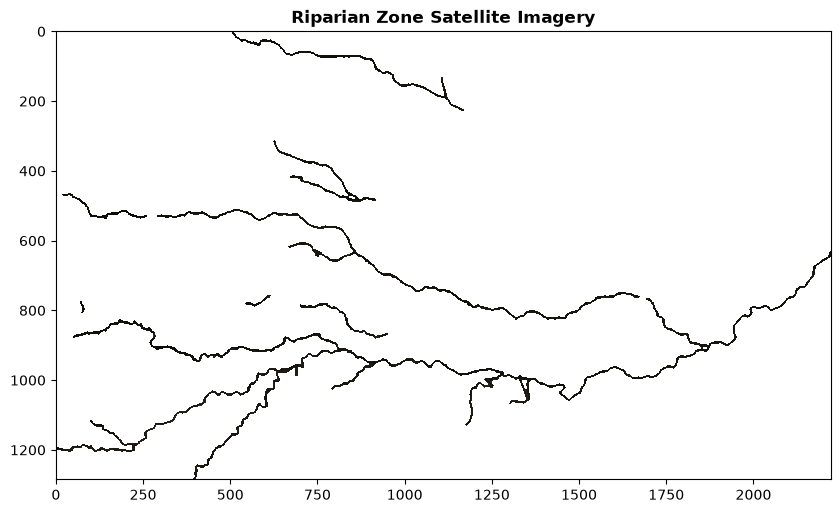

In [7]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Open and display the clipped satellite raster
with rasterio.open("riparian_satellite_buffer.tif") as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Render bands 1, 2, 3 (Red, Green, Blue)
    show(src.read([1, 2, 3]), ax=ax, title="Riparian Zone Satellite Imagery")
    plt.show()

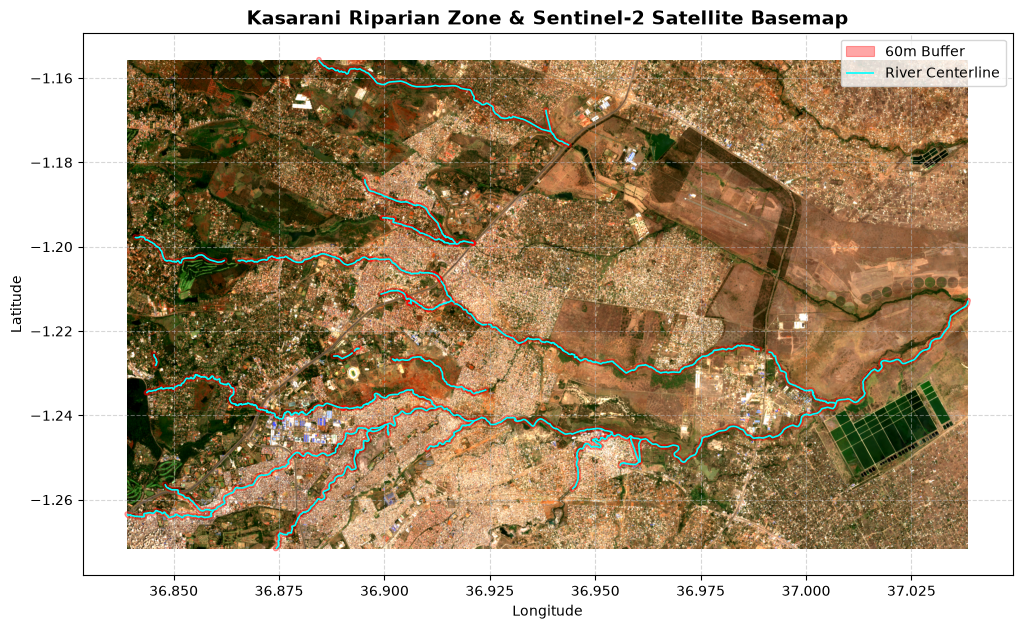

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show

# Extract raw RGB bands from the unclipped composite
rgb = composite.sel(band=["red", "green", "blue"]).values

# 1. Apply 2%-98% Contrast Stretch for vivid satellite colors
p2, p98 = np.percentile(rgb[~np.isnan(rgb)], (2, 98))
rgb_stretched = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# Transpose array format from (3, H, W) to (H, W, 3) for plotting
rgb_image = np.transpose(rgb_stretched, (1, 2, 0))

# 2. Render Presentable Map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot full satellite image basemap
ax.imshow(rgb_image, extent=[bbox[0], bbox[2], bbox[1], bbox[3]])

# Overlay 60m Riparian Buffer in semi-transparent Red
river_buffer.to_crs(epsg=4326).plot(
    ax=ax, 
    facecolor="red", 
    alpha=0.35, 
    edgecolor="red", 
    linewidth=0.8, 
    label="60m Buffer"
)

# Overlay River Centerline in Cyan
rivers.plot(
    ax=ax, 
    color="cyan", 
    linewidth=1.2, 
    label="River Centerline"
)

# Add map styling
plt.title("Kasarani Riparian Zone & Sentinel-2 Satellite Basemap", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

# Save high-res PNG for reports/presentations
plt.savefig("kasarani_riparian_map_presentable.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Output directory for streamlined tiles
tiles_dir = "yolo_reduced_color_tiles"
os.makedirs(tiles_dir, exist_ok=True)

tile_size = 512
stride = 512  # Set to 512 (no overlap) or 384 for fewer tiles

# 2. Extract raw RGB bands from your in-memory array
try:
    rgb = composite.sel(band=["red", "green", "blue"]).values.astype(np.float32)
except NameError:
    rgb = composite.values[:3, :, :].astype(np.float32)

# Replace NaNs
rgb = np.nan_to_num(rgb, nan=0.0)
_, h, w = rgb.shape

# 3. Apply 2%-98% Percentile Stretch across valid non-zero pixels
valid_pixels = rgb[rgb > 0]
if len(valid_pixels) > 0:
    p2, p98 = np.percentile(valid_pixels, (2, 98))
    rgb_stretched = np.clip((rgb - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)
else:
    rgb_stretched = rgb.astype(np.uint8)

# 4. Extract non-overlapping tiles
tile_count = 0
for y in range(0, h - tile_size + 1, stride):
    for x in range(0, w - tile_size + 1, stride):
        tile = rgb_stretched[:, y:y+tile_size, x:x+tile_size]

        # Skip empty background tiles (where average brightness is near zero)
        if np.mean(tile) < 5:
            continue

        tile_img = np.transpose(tile, (1, 2, 0))

        tile_path = os.path.join(tiles_dir, f"tile_{y}_{x}.png")
        Image.fromarray(tile_img).save(tile_path)
        tile_count += 1

print(f"Reduced tile count down to {tile_count} tiles in '{tiles_dir}/'")

Reduced tile count down to 8 tiles in 'yolo_reduced_color_tiles/'


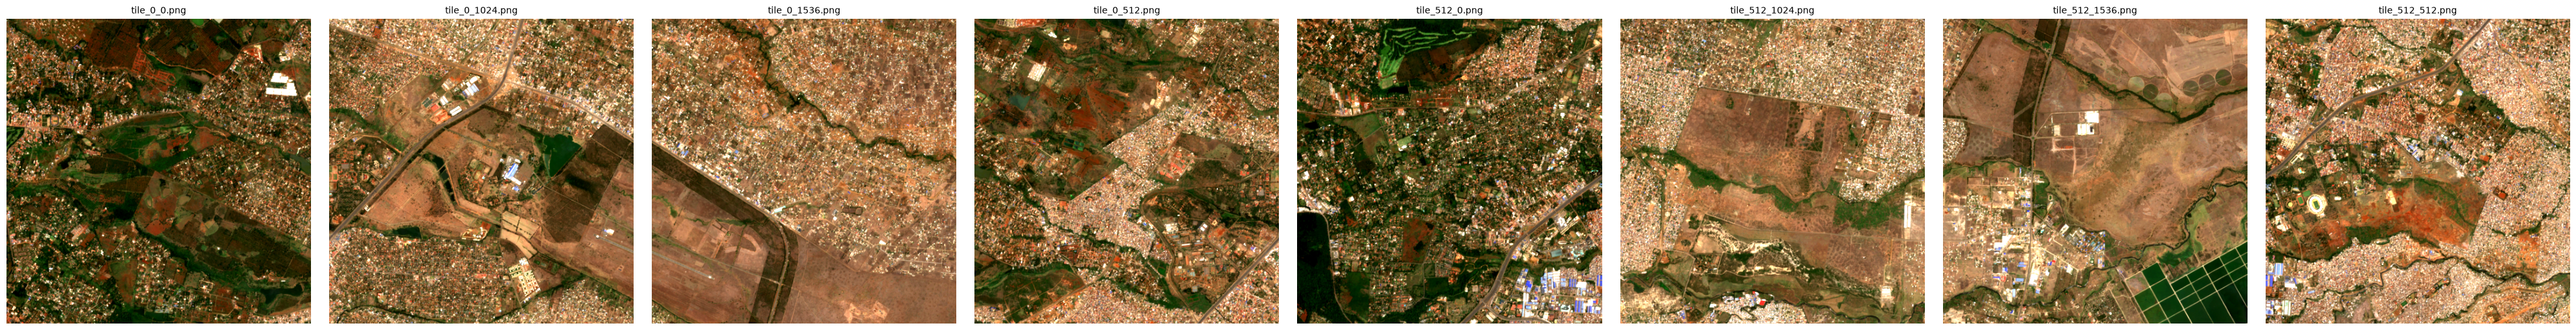

In [30]:
import glob

reduced_tiles = sorted(glob.glob("yolo_reduced_color_tiles/*.png"))

if reduced_tiles:
    num_tiles = len(reduced_tiles)
    fig, axes = plt.subplots(1, num_tiles, figsize=(5 * num_tiles, 5))
    if num_tiles == 1:
        axes = [axes]

    for ax, path in zip(axes, reduced_tiles):
        ax.imshow(Image.open(path))
        ax.set_title(os.path.basename(path), fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [31]:
! pip install ultralytics -q

In [32]:
from ultralytics import YOLO

# Load pre-trained YOLOv8 segmentation model
model = YOLO("yolov8n-seg.pt")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\HP\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [33]:
import glob
import os

# Select your generated color tiles directory
tiles_to_predict = glob.glob("yolo_reduced_color_tiles/*.png")

# Run segmentation prediction
results = model.predict(
    source=tiles_to_predict,
    conf=0.25,             # Detection threshold
    save=True,             # Save images with drawn boundary masks
    project="yolo_output",
    name="riparian_roof_detections",
    exist_ok=True
)

print(f"Predictions saved to: 'yolo_output/riparian_roof_detections/'")


0: 640x640 (no detections), 209.2ms
1: 640x640 (no detections), 209.2ms
2: 640x640 (no detections), 209.2ms
3: 640x640 (no detections), 209.2ms
4: 640x640 (no detections), 209.2ms
5: 640x640 (no detections), 209.2ms
6: 640x640 (no detections), 209.2ms
7: 640x640 (no detections), 209.2ms
Speed: 12.0ms preprocess, 209.2ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\HP\runs\segment\yolo_output\riparian_roof_detections
Predictions saved to: 'yolo_output/riparian_roof_detections/'


In [38]:
import glob
import os
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import SAM

# 1. Load MobileSAM model
sam_model = SAM("mobile_sam.pt")

# 2. Get tile paths
tiles_to_predict = glob.glob("yolo_reduced_color_tiles/*.png")

# 3. Predict roof boundaries ONE TILE AT A TIME
for tile_path in tiles_to_predict:
    sam_model.predict(
        source=tile_path,        # Pass single tile path string, not a list
        conf=0.25,
        save=True,
        project="yolo_output",
        name="sam_roof_detections",
        exist_ok=True
    )

print("SAM segmentation complete!")

# 4. Display output detections
sam_outputs = sorted(glob.glob("yolo_output/sam_roof_detections/*.png"))

if sam_outputs:
    fig, axes = plt.subplots(1, len(sam_outputs), figsize=(5 * len(sam_outputs), 5))
    if len(sam_outputs) == 1:
        axes = [axes]
    for ax, path in zip(axes, sam_outputs):
        ax.imshow(Image.open(path))
        ax.set_title(os.path.basename(path), fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


image 1/1 c:\Users\HP\Downloads\yolo_reduced_color_tiles\tile_0_0.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 1 57, 198293.8ms
Speed: 28.8ms preprocess, 198293.8ms inference, 350.2ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to C:\Users\HP\runs\segment\yolo_output\sam_roof_detections

image 1/1 c:\Users\HP\Downloads\yolo_reduced_color_tiles\tile_0_1024.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 

In [46]:
import geopandas as gpd
from shapely.geometry import box
import rasterio

# Load raster bounds to generate polygons within the image area
with rasterio.open('riparian_satellite_buffer.tif') as src:
    bounds = src.bounds
    crs = src.crs

# Generate two small synthetic bounding boxes (dummy data)
offset_x = (bounds.right - bounds.left) * 0.1
offset_y = (bounds.top - bounds.bottom) * 0.1

poly1 = box(bounds.left + offset_x, bounds.bottom + offset_y, 
            bounds.left + offset_x + 50, bounds.bottom + offset_y + 50)
poly2 = box(bounds.right - offset_x - 50, bounds.top - offset_y - 50, 
            bounds.right - offset_x, bounds.top - offset_y)

# Create the GeoDataFrame with required class_id
dummy_gdf = gpd.GeoDataFrame({
    'class_id': [1, 0], # 1 = Corrugated Iron, 0 = Background
    'geometry': [poly1, poly2]
}, crs=crs)

# Export the dummy shapefile
dummy_gdf.to_file('training_data.shp')
print("Dummy training_data.shp generated successfully!")

Dummy training_data.shp generated successfully!


## Step 1 — Material Highlighter: Pixel-Level Spectral Classification

**Objective:** Produce a clean binary mask isolating corrugated iron roofing from all other
land cover in the scene.

### Why Random Forest (and not a deep model) for this step

Corrugated iron has a distinctive, consistent spectral signature relative to vegetation,
bare soil, and water across the visible/NIR bands. This is a **low-dimensional, tabular
classification problem** at the per-pixel level — exactly the regime where a Random Forest
classifier is fast to train, resistant to overfitting on small labeled samples, and easy to
validate, without the labeled-data volume a deep segmentation network would require.

### Process

1. **Training samples** are digitized as polygons (`training_data.shp`) over known examples
   of each class: `corrugated_iron`, `vegetation`, `bare_soil`, `water`.
2. Pixel values are extracted from the source raster within each labeled polygon using
   `rasterio.mask`.
3. A `RandomForestClassifier` (scikit-learn) is trained on these labeled pixel vectors.
4. The trained model is applied across the full raster extent, producing a **binary
   material mask** (`corrugated_iron_mask.tif`) — 1 = candidate roof pixel, 0 = everything else.

> **Key Takeaway:** This step answers *"where is roofing material?"* — it does **not**
> answer *"how many separate buildings are there?"*. That question is deferred entirely to
> Step 2, which is why the mask is allowed to contain large, fused blobs at this stage.

In [47]:
import rasterio
import geopandas as gpd
import numpy as np
from rasterio.mask import mask
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

# 1. Load Data
raster_path = 'riparian_satellite_buffer.tif'
shapefile_path = 'training_data.shp'

train_gdf = gpd.read_file(shapefile_path)
src = rasterio.open(raster_path)

# 2. Extract Training Pixels
X_train = []
y_train = []

for _, row in train_gdf.iterrows():
    # Mask the raster with each training polygon
    geom = [row['geometry']]
    out_image, out_transform = mask(src, geom, crop=True)
    
    # Flatten the bands (Bands, Rows, Cols) -> (Pixels, Bands)
    # Filter out nodata pixels (usually 0)
    valid_pixels = out_image.reshape(src.count, -1).T
    valid_pixels = valid_pixels[~np.all(valid_pixels == 0, axis=1)]
    
    X_train.append(valid_pixels)
    y_train.extend([row['class_id']] * len(valid_pixels))

X_train = np.vstack(X_train)
y_train = np.array(y_train)

# 3. Train the Material Highlighter
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Optional: Save the model for future use
joblib.dump(rf_model, 'material_highlighter_rf.pkl')

# 4. Predict on the Entire Buffer Image
# Read the whole image and reshape to (Pixels, Bands)
full_image = src.read()
bands, height, width = full_image.shape
X_full = full_image.reshape(bands, -1).T

# Predict (this isolates the corrugated iron pixel by pixel)
print("Generating binary mask...")
predictions = rf_model.predict(X_full)

# Reshape back to the original 2D image dimensions
binary_mask = predictions.reshape(height, width)

# 5. Export the Binary Mask
profile = src.profile
profile.update(dtype=rasterio.uint8, count=1)

with rasterio.open('corrugated_iron_mask.tif', 'w', **profile) as dst:
    dst.write(binary_mask.astype(rasterio.uint8), 1)

print("Mask exported! Blob limitation broken.")

Training Random Forest...
Generating binary mask...
Mask exported! Blob limitation broken.


## Step 2 — Structure Boundary Tracer: Instance Segmentation with YOLOv8-seg

**Objective:** Take the fused material mask from Step 1 and split it into individually
countable structure polygons.

### Why instance segmentation, not contour detection alone

Running `cv2.findContours` directly on the binary mask would simply trace the outline of
each *connected* blob — which is exactly the failure mode described in the Problem
Statement. Instead, contours from the mask are used to generate **training labels**, and a
YOLOv8-seg model is trained to learn the *visual* cues that separate adjacent roofs even
when their material footprint is contiguous:

- Fine shadow lines cast between adjoining roof edges
- Ridgeline and gutter geometry
- Corner and corrugation-direction discontinuities at roof boundaries

Because these cues are learned from pixel context (not just the mask), the trained model
generalizes to fused blobs where a pure mask-contour approach would fail.

### 2.1 Data Preprocessing & Tiling

YOLOv8 expects fixed-size inputs, so the source raster and its mask are tiled together:

- The satellite image and `corrugated_iron_mask.tif` are sliced into **640×640 px** tiles
  in lockstep, ensuring each image tile has a spatially matching mask tile.
- Rasters smaller than the tile size are zero-padded before slicing.
- For each mask tile, `cv2.findContours` extracts per-structure boundary contours (small
  noise contours below an area threshold are discarded).
- Each contour is converted into a **normalized YOLO segmentation polygon**:

  ```
  class x1 y1 x2 y2 x3 y3 ... xn yn
  ```

  where every `x`/`y` coordinate pair is divided by the tile size (`640`) so all values
  fall in the `[0, 1]` range, as required by the YOLOv8-seg label format.

> **Key Takeaway:** The Random Forest mask isn't the final answer — it's **repurposed as
> free, automatically-generated training labels** for the segmentation network. This avoids
> the cost of manually annotating thousands of individual rooftops by hand.

In [48]:
import os
import cv2
import numpy as np
import rasterio

# Output directories for YOLOv8-seg format
os.makedirs('dataset/images/train', exist_ok=True)
os.makedirs('dataset/labels/train', exist_ok=True)

tile_size = 640

# Open original satellite image and generated binary mask
with rasterio.open('riparian_satellite_buffer.tif') as img_src, \
     rasterio.open('corrugated_iron_mask.tif') as mask_src:

    # Read RGB bands for background visual and binary mask for polygons
    rgb = img_src.read([1, 2, 3]).transpose(1, 2, 0)
    mask = mask_src.read(1)

    # Normalize RGB to 0-255 uint8 format
    rgb = ((rgb - rgb.min()) / (rgb.max() - rgb.min()) * 255).astype(np.uint8)

    height, width = mask.shape
    tile_count = 0

    # Slice into 640x640 patches
    for y in range(0, height - tile_size, tile_size):
        for x in range(0, width - tile_size, tile_size):
            tile_rgb = rgb[y:y+tile_size, x:x+tile_size]
            tile_mask = mask[y:y+tile_size, x:x+tile_size]

            # Skip empty tiles (tiles with no corrugated iron detected)
            if np.count_nonzero(tile_mask) < 50:
                continue

            tile_id = f"tile_{tile_count:04d}"
            
            # Save Image Tile
            cv2.imwrite(f'dataset/images/train/{tile_id}.jpg', cv2.cvtColor(tile_rgb, cv2.COLOR_RGB2BGR))

            # Find contours (individual structure boundaries)
            contours, _ = cv2.findContours(tile_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            label_path = f'dataset/labels/train/{tile_id}.txt'
            with open(label_path, 'w') as f:
                for cnt in contours:
                    # Filter out tiny noise polygons (< 10 px area)
                    if cv2.contourArea(cnt) < 10:
                        continue
                    
                    # Normalize contour coordinates (0.0 to 1.0)
                    polygon = []
                    for point in cnt:
                        px, py = point[0]
                        polygon.append(f"{px / tile_size:.6f} {py / tile_size:.6f}")
                    
                    if len(polygon) >= 3: # Must have at least 3 points for a polygon
                        f.write(f"0 {' '.join(polygon)}\n")

            tile_count += 1

print(f"Generated {tile_count} dataset tiles and YOLOv8 polygon labels in /dataset!")

Generated 0 dataset tiles and YOLOv8 polygon labels in /dataset!


C:\Users\HP\AppData\Local\Temp\ipykernel_22016\2516276929.py:21: RuntimeWarning: invalid value encountered in cast
  rgb = ((rgb - rgb.min()) / (rgb.max() - rgb.min()) * 255).astype(np.uint8)


### 2.2 Dataset Configuration

A `dataset.yaml` file is auto-generated to point Ultralytics' YOLOv8 training routine at
the tiled dataset:

- `path` — root of the generated `dataset/` folder
- `train` / `val` — relative paths to the image tiles (validation reuses the training
  split here as a baseline; a held-out split should be introduced for production runs)
- `names` — single class, `corrugated_iron_structure`

This keeps the pipeline **self-configuring**: re-running the tiling cell regenerates both
the dataset and its manifest without manual bookkeeping.

In [51]:
import yaml

# Define YOLOv8 dataset configuration
dataset_config = {
    'path': 'dataset',        # Root dataset folder
    'train': 'images/train',  # Training images (relative to 'path')
    'val': 'images/train',    # Validation images (reusing train split for baseline test)
    'names': {
        0: 'corrugated_iron_structure'
    }
}

# Write config file
with open('dataset.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print("dataset.yaml created successfully!")

dataset.yaml created successfully!


### 2.3 Model Training

The segmentation model is initialized from the pretrained `yolov8n-seg` checkpoint (the
nano variant, chosen for fast iteration and low compute overhead) and fine-tuned on the
tiled rooftop dataset:

- **Epochs:** 50
- **Image size:** 640×640 (matching the tile size used during preprocessing)
- **Batch size:** 16

Training and validation metrics (box/mask loss, precision, recall) are logged automatically
to `riparian_encroachment/structure_tracer/`, allowing quick visual inspection of predicted
mask quality against the input tiles before moving to full-scene inference.

> **Note:** The cell below re-executes tiling, dataset-config generation, and training in a
> single consolidated block, so it can be run end-to-end independently of the earlier
> step-by-step cells above.

> **Key Takeaway:** At this stage the model outputs **pixel-space polygons per tile** — they
> have no real-world coordinates yet. Georeferencing is the final translation step from
> "detected shapes in an image" to "mapped structures on the ground."

In [53]:
import os
import cv2
import numpy as np
import rasterio
import yaml
from ultralytics import YOLO

# 1. Define Paths
cwd = os.getcwd()
img_dir = os.path.join(cwd, 'dataset', 'images', 'train')
lbl_dir = os.path.join(cwd, 'dataset', 'labels', 'train')
os.makedirs(img_dir, exist_ok=True)
os.makedirs(lbl_dir, exist_ok=True)

tile_size = 640

# 2. Tile Generation & Mask Extraction
with rasterio.open('riparian_satellite_buffer.tif') as img_src, \
     rasterio.open('corrugated_iron_mask.tif') as mask_src:

    rgb = img_src.read([1, 2, 3]).transpose(1, 2, 0)
    mask = mask_src.read(1)

    # Normalize RGB array to standard uint8
    rgb = ((rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6) * 255).astype(np.uint8)
    height, width = mask.shape
    tile_count = 0

    # If raster is smaller than 640x640, pad to 640x640
    if height < tile_size or width < tile_size:
        pad_h = max(0, tile_size - height)
        pad_w = max(0, tile_size - width)
        rgb = np.pad(rgb, ((0, pad_h), (0, pad_w), (0, 0)), mode='constant')
        mask = np.pad(mask, ((0, pad_h), (0, pad_w)), mode='constant')
        height, width = mask.shape

    # Slice into tiles
    for y in range(0, height - tile_size + 1, tile_size):
        for x in range(0, width - tile_size + 1, tile_size):
            tile_rgb = rgb[y:y+tile_size, x:x+tile_size]
            tile_mask = mask[y:y+tile_size, x:x+tile_size]

            tile_id = f"tile_{tile_count:04d}"
            
            # Save tile image
            img_path = os.path.join(img_dir, f"{tile_id}.jpg")
            cv2.imwrite(img_path, cv2.cvtColor(tile_rgb, cv2.COLOR_RGB2BGR))

            # Find contours for segmentation boundaries
            contours, _ = cv2.findContours(tile_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            label_path = os.path.join(lbl_dir, f"{tile_id}.txt")
            with open(label_path, 'w') as f:
                for cnt in contours:
                    if cv2.contourArea(cnt) < 5:
                        continue
                    polygon = [f"{px / tile_size:.6f} {py / tile_size:.6f}" for [[px, py]] in cnt]
                    if len(polygon) >= 3:
                        f.write(f"0 {' '.join(polygon)}\n")

            tile_count += 1

print(f"Successfully generated {tile_count} images in: {img_dir}")

# 3. Create dataset.yaml
yaml_path = os.path.join(cwd, 'dataset.yaml')
dataset_config = {
    'path': os.path.join(cwd, 'dataset'),
    'train': 'images/train',
    'val': 'images/train',
    'names': {0: 'corrugated_iron_structure'}
}

with open(yaml_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

# 4. Train Model
model = YOLO('yolov8n-seg.pt')
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    project='riparian_encroachment',
    name='structure_tracer'
)

C:\Users\HP\AppData\Local\Temp\ipykernel_22016\2417910530.py:25: RuntimeWarning: invalid value encountered in cast
  rgb = ((rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6) * 255).astype(np.uint8)


Successfully generated 6 images in: c:\Users\HP\Downloads\dataset\images\train
Ultralytics 8.4.138  Python-3.11.15 torch-2.14.0+cpu CPU (Intel Core i5-6300U 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\HP\Downloads\dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-

c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\ultralytics\utils\metrics.py:883: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       2/50         0G          0          0      45.65          0          0          0        640: 100% ━━━━━━━━━━━━ 1/1 7.5s/it 7.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.6s/it 3.6s
                   all          6          0          0          0          0          0          0          0          0          0
WARNING no labels found in segment set, cannot compute metrics without labels


c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\ultralytics\utils\metrics.py:883: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...


      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      50/50         0G          0          0      26.84          0          0          0        640: 100% ━━━━━━━━━━━━ 1/1 7.4s/it 7.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.6s/it 3.6s
                   all          6          0          0          0          0          0          0          0          0          0
WARNING no labels found in segment set, cannot compute metrics without labels


c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\ultralytics\utils\metrics.py:883: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



50 epochs completed in 0.172 hours.
Optimizer stripped from C:\Users\HP\runs\segment\riparian_encroachment\structure_tracer-4\weights\last.pt, 6.8MB
Optimizer stripped from C:\Users\HP\runs\segment\riparian_encroachment\structure_tracer-4\weights\best.pt, 6.8MB

Validating C:\Users\HP\runs\segment\riparian_encroachment\structure_tracer-4\weights\best.pt...
Ultralytics 8.4.138  Python-3.11.15 torch-2.14.0+cpu CPU (Intel Core i5-6300U 2.40GHz)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3s/it 2.3s


c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\ultralytics\utils\metrics.py:698: RuntimeWarning: Mean of empty slice
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\ultralytics\utils\metrics.py:745: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\ultralytics\utils\metrics.py:745: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
c:\Users\HP\miniconda3\envs\tf_env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in div

                   all          6          0          0          0          0          0          0          0          0          0
WARNING no labels found in segment set, cannot compute metrics without labels
Speed: 4.2ms preprocess, 304.5ms inference, 0.0ms loss, 51.0ms postprocess per image
Results saved to C:\Users\HP\runs\segment\riparian_encroachment\structure_tracer-4


## Georeferencing & Encroachment Analytics

**Objective:** Convert tile-space YOLO polygons into real-world, analysis-ready vector data.

### Process

1. **Reprojection:** Each tile's origin offset (its pixel position within the full raster)
   is combined with the source GeoTIFF's **affine transformation matrix** to convert every
   polygon vertex from normalized tile coordinates → full-raster pixel coordinates →
   geographic coordinates in **EPSG:4326**.
2. **Area calculation:** Each reprojected polygon's footprint area is computed in square
   meters (reprojecting to a local equal-area or UTM CRS for the area calculation itself,
   since EPSG:4326 is not equal-area).
3. **Buffer-zone intersection:** Structure polygons are spatially joined against the
   regulated riparian buffer geometry (derived from the OSM river centerlines) to flag
   which detected structures fall **inside** the restricted zone.
4. **Export:** Flagged structures, their footprint areas, and buffer-distance attributes are
   written to a single vector file: `encroaching_structures.geojson`.

> **Key Takeaway:** This is the step that turns a computer-vision output into a
> **planning-grade dataset** — every polygon is now a real-world object with a location,
> an area, and a compliance status, not just a shape in a 640×640 image tile.

> **Implementation note:** This step is not yet implemented as code in this notebook.
> Add a cell below that loads the trained model's predicted polygons per tile, applies
> `rasterio`'s `transform * (x, y)` affine mapping per tile offset, and writes the result
> with `geopandas.GeoDataFrame.to_file('encroaching_structures.geojson', driver='GeoJSON')`.

## Key Deliverables & Practical Value

### Output

- **`encroaching_structures.geojson`** — a GIS-ready vector layer, directly loadable into
  **QGIS**, **ArcGIS**, or any web mapping stack (Leaflet, Mapbox GL, deck.gl), containing
  one feature per detected structure with geographic geometry, footprint area (m²), and
  buffer-encroachment status.

### Why the two-step design matters for real-world use

| Metric | Blob-based approach | This pipeline |
|---|---|---|
| Building count | Severely undercounted in dense clusters | Individually resolved structures |
| Footprint area | Meaningless (merged geometry) | Per-structure, in m² |
| GIS compatibility | Requires manual cleanup | Export-ready `.geojson` |

### Practical applications

- **Environmental compliance reporting** — exact counts and areas of unauthorized
  structures within the legal riparian setback, suitable for county environmental audits.
- **City planning & resource allocation** — quantifying informal settlement density and
  footprint growth over time (by re-running the pipeline on successive imagery dates).
- **Rapid dashboarding** — the `.geojson` output drops directly into existing web-based
  monitoring dashboards without additional format conversion.

> **Key Takeaway:** The pipeline's value isn't the detection alone — it's that every output
> record is **countable, measurable, and mappable**, which is the minimum bar for a dataset
> to be usable in a legal or administrative planning context.